In [1]:

import os, glob, time, warnings
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.patches as mpatches
import seaborn as sns

from sklearn.model_selection import train_test_split
from sklearn.preprocessing import RobustScaler, label_binarize
from sklearn.linear_model import LogisticRegression
from sklearn.tree import DecisionTreeClassifier
from sklearn.ensemble import RandomForestClassifier
from sklearn.svm import SVC
from sklearn.multiclass import OneVsRestClassifier
from sklearn.metrics import (
    accuracy_score, precision_score, recall_score, f1_score,
    confusion_matrix, roc_curve, auc, classification_report,
    ConfusionMatrixDisplay
)
from xgboost import XGBClassifier

warnings.filterwarnings("ignore")
np.random.seed(42)

CLASS_NAMES = [
    "No Failure",
    "Thermal Failure",
    "Mechanical Failure",
    "Hydraulic Failure",
    "Wear-Out Failure"
]
N_CLASSES = len(CLASS_NAMES)
PALETTE   = ["#27ae60","#e74c3c","#f39c12","#3498db","#9b59b6"]


def banner(title: str) -> None:
    line = "=" * 70
    print(f"\n{line}\n  {title}\n{line}")


In [3]:
banner("STEP 1 – LOADING DATASET")

# 1. Define the exact path to your CSV file
FILE_PATH = "/home/algosium/Documents/prd-analysis/data/Large_Industrial_Pump_Maintenance_Dataset.csv"

# 2. Read the file directly into your dataframe
df_raw = pd.read_csv(FILE_PATH)

# 3. Print the summary info
print(f"  File   : {FILE_PATH}")
print(f"  Shape  : {df_raw.shape}")
print(f"  Columns: {list(df_raw.columns)}")
print(df_raw.head())


  STEP 1 – LOADING DATASET
  File   : /home/algosium/Documents/prd-analysis/data/Large_Industrial_Pump_Maintenance_Dataset.csv
  Shape  : (20000, 8)
  Columns: ['Pump_ID', 'Temperature', 'Vibration', 'Pressure', 'Flow_Rate', 'RPM', 'Operational_Hours', 'Maintenance_Flag']
   Pump_ID  Temperature  Vibration    Pressure  Flow_Rate          RPM  \
0        2   127.508350   2.369397  136.021029   6.501492  1444.191922   
1        4    88.975185   4.541126  147.516973   7.001516  1004.802496   
2        3    61.832325   2.542112  220.858577   8.824368  2597.662712   
3        3   106.250344   2.834452  145.817091  16.283512  2280.926281   
4        2    84.815865   3.119709  235.476221   8.385183  2594.131667   

   Operational_Hours  Maintenance_Flag  
0        3966.793672                 1  
1        3673.288933                 0  
2        5489.061016                 1  
3        3134.783015                 0  
4         761.533173                 1  


In [4]:

banner("STEP 2 – CREATING MULTI-CLASS FAILURE TYPE LABELS")

df = df_raw.copy()

# ── Thresholds (based on real data percentiles) ───────────────────────────────
#   These mirror what industrial engineers use in practice:
T_HIGH   = df["Temperature"].quantile(0.80)        # 133 °C  → thermal danger
T_CRIT   = df["Temperature"].quantile(0.90)        # 140 °C  → critical thermal
VIB_HIGH = df["Vibration"].quantile(0.80)          # 4.25    → bearing wear
VIB_CRIT = df["Vibration"].quantile(0.90)          # 4.50    → critical vibration
P_HIGH   = df["Pressure"].quantile(0.80)           # 270 bar → pressure stress
FL_LOW   = df["Flow_Rate"].quantile(0.20)          # 3.6     → low flow / blockage
RPM_HIGH = df["RPM"].quantile(0.80)                # 2709    → overspeed
HRS_HIGH = df["Operational_Hours"].quantile(0.75)  # 7504 h  → aged pump
HRS_CRIT = df["Operational_Hours"].quantile(0.90)  # 9024 h  → very old pump

print(f"  Thresholds used:")
print(f"    Temperature  HIGH={T_HIGH:.1f}  CRIT={T_CRIT:.1f}  °C")
print(f"    Vibration    HIGH={VIB_HIGH:.2f}  CRIT={VIB_CRIT:.2f}")
print(f"    Pressure     HIGH={P_HIGH:.1f}  bar")
print(f"    Flow Rate    LOW ={FL_LOW:.2f}  L/s")
print(f"    RPM          HIGH={RPM_HIGH:.0f}")
print(f"    Op. Hours    HIGH={HRS_HIGH:.0f}  CRIT={HRS_CRIT:.0f}")

# ── Score each failure mode independently ────────────────────────────────────

# Thermal score  → driven by Temperature
thermal_score = (
    (df["Temperature"] > T_HIGH ).astype(int) * 2
  + (df["Temperature"] > T_CRIT ).astype(int) * 2
  + (df["RPM"]         > RPM_HIGH).astype(int) * 1   # high RPM generates heat
)

# Mechanical score → driven by Vibration
mechanical_score = (
    (df["Vibration"] > VIB_HIGH).astype(int) * 3
  + (df["Vibration"] > VIB_CRIT).astype(int) * 2
  + (df["RPM"]       > RPM_HIGH).astype(int) * 1     # overspeed causes vibration
)

# Hydraulic score → driven by Pressure & Flow Rate
hydraulic_score = (
    (df["Pressure"]  > P_HIGH ).astype(int) * 2
  + (df["Flow_Rate"] < FL_LOW ).astype(int) * 3      # low flow = blockage/cavitation
  + (df["Pressure"]  > df["Pressure"].quantile(0.90)).astype(int) * 1
)

# Wear-Out score → driven by Operational Hours
wearout_score = (
    (df["Operational_Hours"] > HRS_HIGH).astype(int) * 2
  + (df["Operational_Hours"] > HRS_CRIT).astype(int) * 2
  + (df["Vibration"]         > VIB_HIGH).astype(int) * 1  # old pump vibrates more
)

THRESHOLD = 3   # minimum score to classify as that failure type

thermal_flag    = (thermal_score    >= THRESHOLD).astype(int)
mechanical_flag = (mechanical_score >= THRESHOLD).astype(int)
hydraulic_flag  = (hydraulic_score  >= THRESHOLD).astype(int)
wearout_flag    = (wearout_score    >= THRESHOLD).astype(int)

# ── Assign final class (priority: Mechanical > Thermal > Hydraulic > WearOut) ─
# When a pump has multiple failure signals, assign the MOST CRITICAL one
def assign_failure_type(row):
    mech  = row["mechanical_flag"]
    therm = row["thermal_flag"]
    hydr  = row["hydraulic_flag"]
    wear  = row["wearout_flag"]

    # Priority order based on industrial severity
    if mech:   return 2   # Mechanical  (sudden, catastrophic)
    if therm:  return 1   # Thermal     (fast damage)
    if hydr:   return 3   # Hydraulic   (progressive)
    if wear:   return 4   # Wear-Out    (gradual)
    return 0              # No Failure

df["thermal_flag"]    = thermal_flag
df["mechanical_flag"] = mechanical_flag
df["hydraulic_flag"]  = hydraulic_flag
df["wearout_flag"]    = wearout_flag

df["Failure_Type"] = df.apply(assign_failure_type, axis=1)

# Drop helper flag columns
df.drop(columns=["thermal_flag","mechanical_flag","hydraulic_flag","wearout_flag"],
        inplace=True)

# ── Show class distribution ───────────────────────────────────────────────────
print("\n  ── Failure Type Distribution ──")
dist = df["Failure_Type"].value_counts().sort_index()
for cls_id, count in dist.items():
    pct = count / len(df) * 100
    bar = "█" * int(pct / 2)
    print(f"  Class {cls_id} | {CLASS_NAMES[cls_id]:<22} | {count:>5} rows ({pct:5.1f}%)  {bar}")



  STEP 2 – CREATING MULTI-CLASS FAILURE TYPE LABELS
  Thresholds used:
    Temperature  HIGH=130.3  CRIT=140.0  °C
    Vibration    HIGH=4.00  CRIT=4.50
    Pressure     HIGH=260.3  bar
    Flow Rate    LOW =4.32  L/s
    RPM          HIGH=2605
    Op. Hours    HIGH=7504  CRIT=9024

  ── Failure Type Distribution ──
  Class 0 | No Failure             |  9104 rows ( 45.5%)  ██████████████████████
  Class 1 | Thermal Failure        |  1903 rows (  9.5%)  ████
  Class 2 | Mechanical Failure     |  4000 rows ( 20.0%)  ██████████
  Class 3 | Hydraulic Failure      |  3968 rows ( 19.8%)  █████████
  Class 4 | Wear-Out Failure       |  1025 rows (  5.1%)  ██


In [5]:

banner("STEP 3 – FEATURE ENGINEERING")

original_cols = ["Pump_ID","Temperature","Vibration","Pressure",
                 "Flow_Rate","RPM","Operational_Hours","Maintenance_Flag"]

# ── Group A: Interaction features ─────────────────────────────────────────────
df["Temp_x_Vibration"]     = df["Temperature"]  * df["Vibration"]
df["Pressure_x_Flow"]      = df["Pressure"]     * df["Flow_Rate"]
df["RPM_x_Vibration"]      = df["RPM"]          * df["Vibration"]
df["Temp_x_RPM"]           = df["Temperature"]  * df["RPM"]

# ── Group B: Ratio features ───────────────────────────────────────────────────
df["Pressure_Flow_Ratio"]  = df["Pressure"]  / (df["Flow_Rate"]          + 1e-6)
df["RPM_per_Hour"]         = df["RPM"]       / (df["Operational_Hours"]  + 1e-6)
df["Power_Proxy"]          = (df["Pressure"] *  df["Flow_Rate"]) / 1000

# ── Group C: Log transforms (reduce skewness) ─────────────────────────────────
df["Log_Vibration"]        = np.log1p(df["Vibration"])
df["Log_Op_Hours"]         = np.log1p(df["Operational_Hours"])

# ── Group D: Polynomial features ──────────────────────────────────────────────
df["Temperature_sq"]       = df["Temperature"] ** 2
df["Vibration_sq"]         = df["Vibration"]   ** 2

# ── Group E: Risk bin features ────────────────────────────────────────────────
df["Hours_Bin"] = pd.cut(
    df["Operational_Hours"],
    bins=[0, 2500, 5000, 7500, 10001],
    labels=[0, 1, 2, 3]
).astype(int)

df["Temp_Bin"] = pd.cut(
    df["Temperature"],
    bins=[0, 75, 100, 125, 151],
    labels=[0, 1, 2, 3]
).astype(int)

new_features = [c for c in df.columns if c not in original_cols + ["Failure_Type"]]
print(f"\n  {len(new_features)} new features created:")
groups = {
    "Interaction" : [f for f in new_features if "x" in f],
    "Ratio"       : [f for f in new_features if "Ratio" in f or "per" in f or "Proxy" in f],
    "Log"         : [f for f in new_features if "Log" in f],
    "Polynomial"  : [f for f in new_features if "_sq" in f],
    "Risk Bins"   : [f for f in new_features if "Bin" in f],
}
for g, feats in groups.items():
    print(f"\n  [{g}]")
    for f in feats:
        print(f"    + {f}")

print(f"\n  Final dataset shape: {df.shape}")





  STEP 3 – FEATURE ENGINEERING

  13 new features created:

  [Interaction]
    + Temp_x_Vibration
    + Pressure_x_Flow
    + RPM_x_Vibration
    + Temp_x_RPM
    + Power_Proxy

  [Ratio]
    + Pressure_Flow_Ratio
    + RPM_per_Hour
    + Power_Proxy
    + Temperature_sq

  [Log]
    + Log_Vibration
    + Log_Op_Hours

  [Polynomial]
    + Temperature_sq
    + Vibration_sq

  [Risk Bins]
    + Hours_Bin
    + Temp_Bin

  Final dataset shape: (20000, 22)



  STEP 4 – EXPLORATORY DATA ANALYSIS


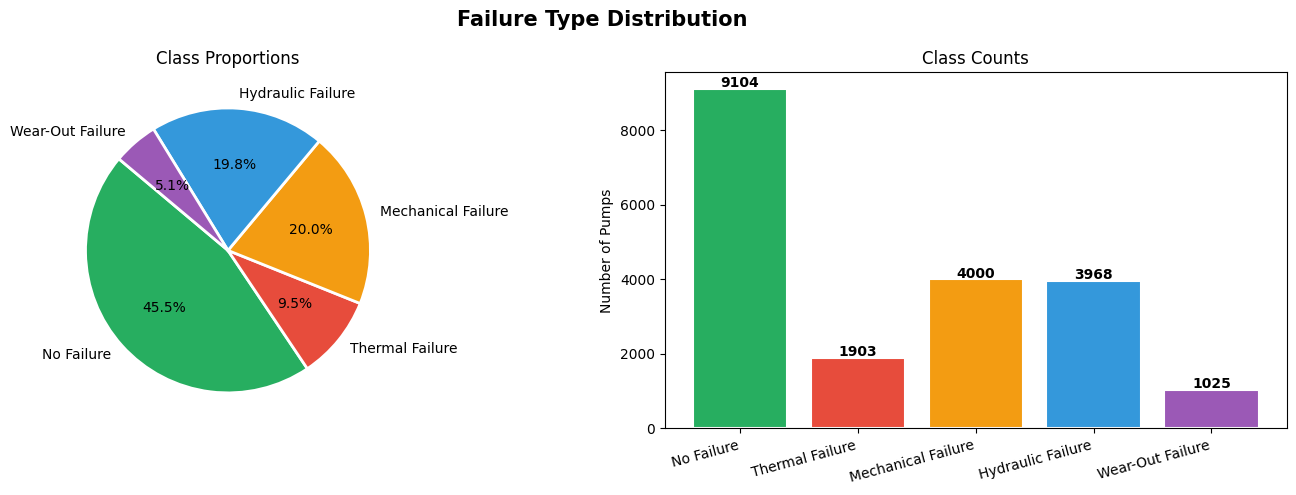

→ Saved: eda_class_distribution.png


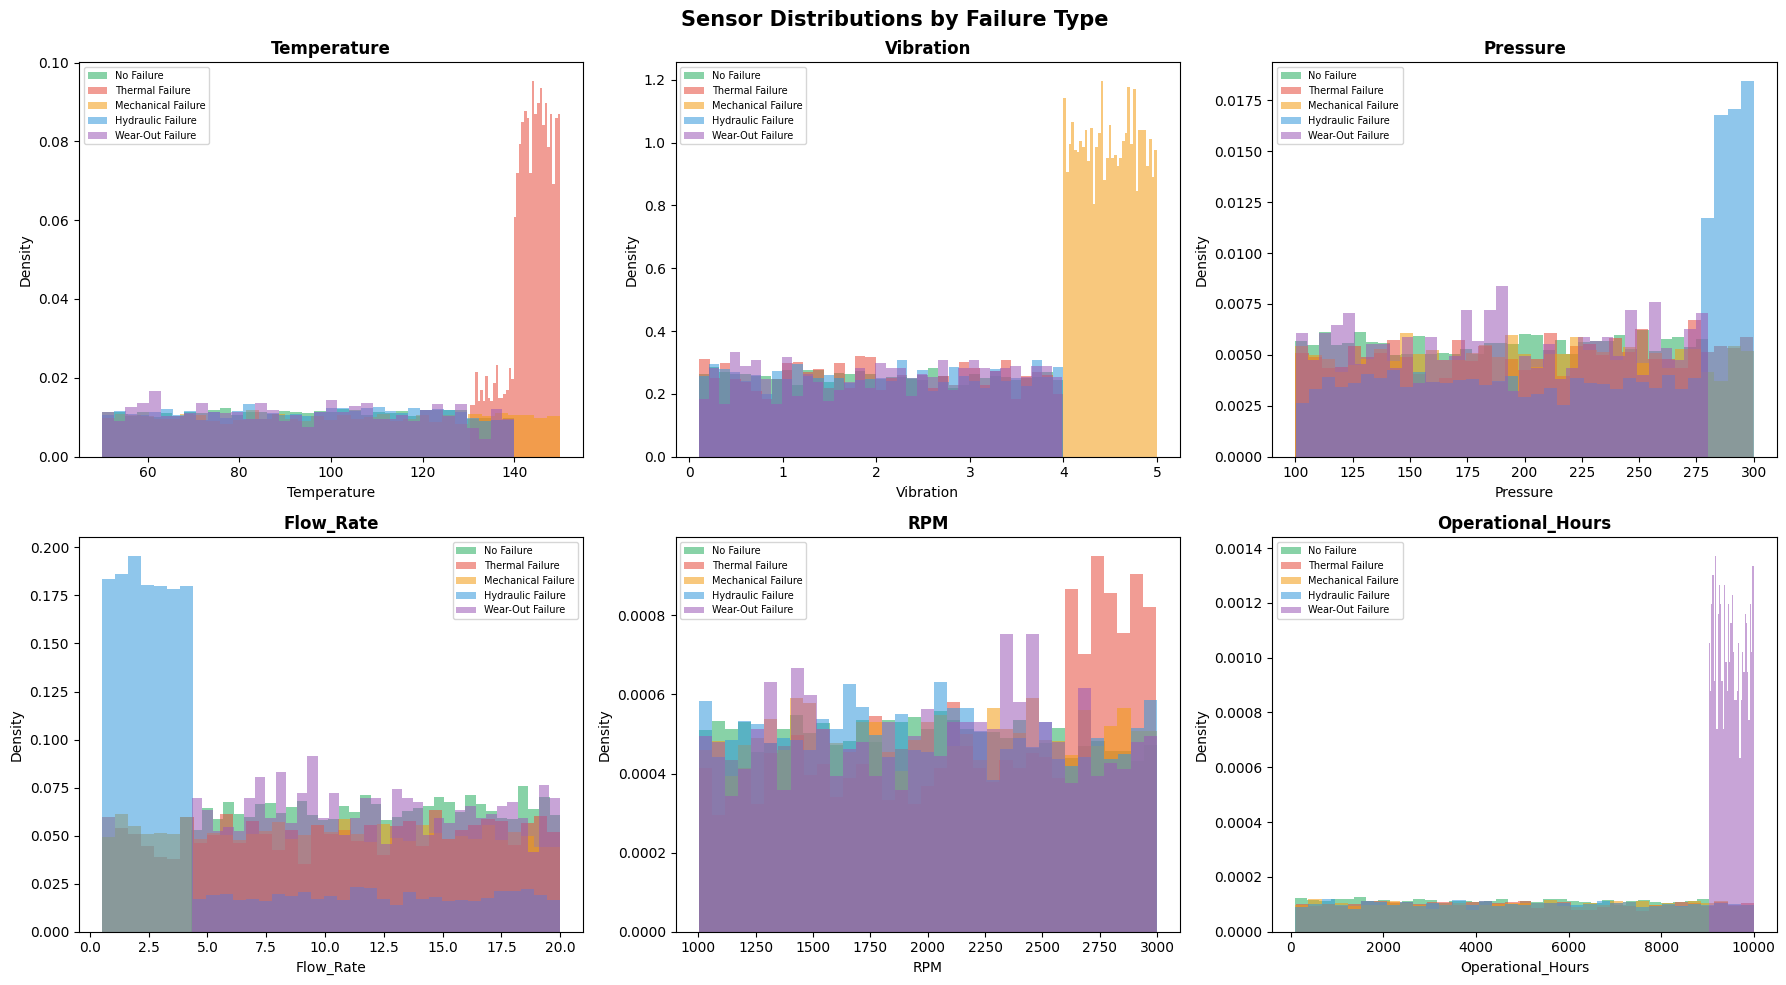

→ Saved: eda_sensor_distributions.png


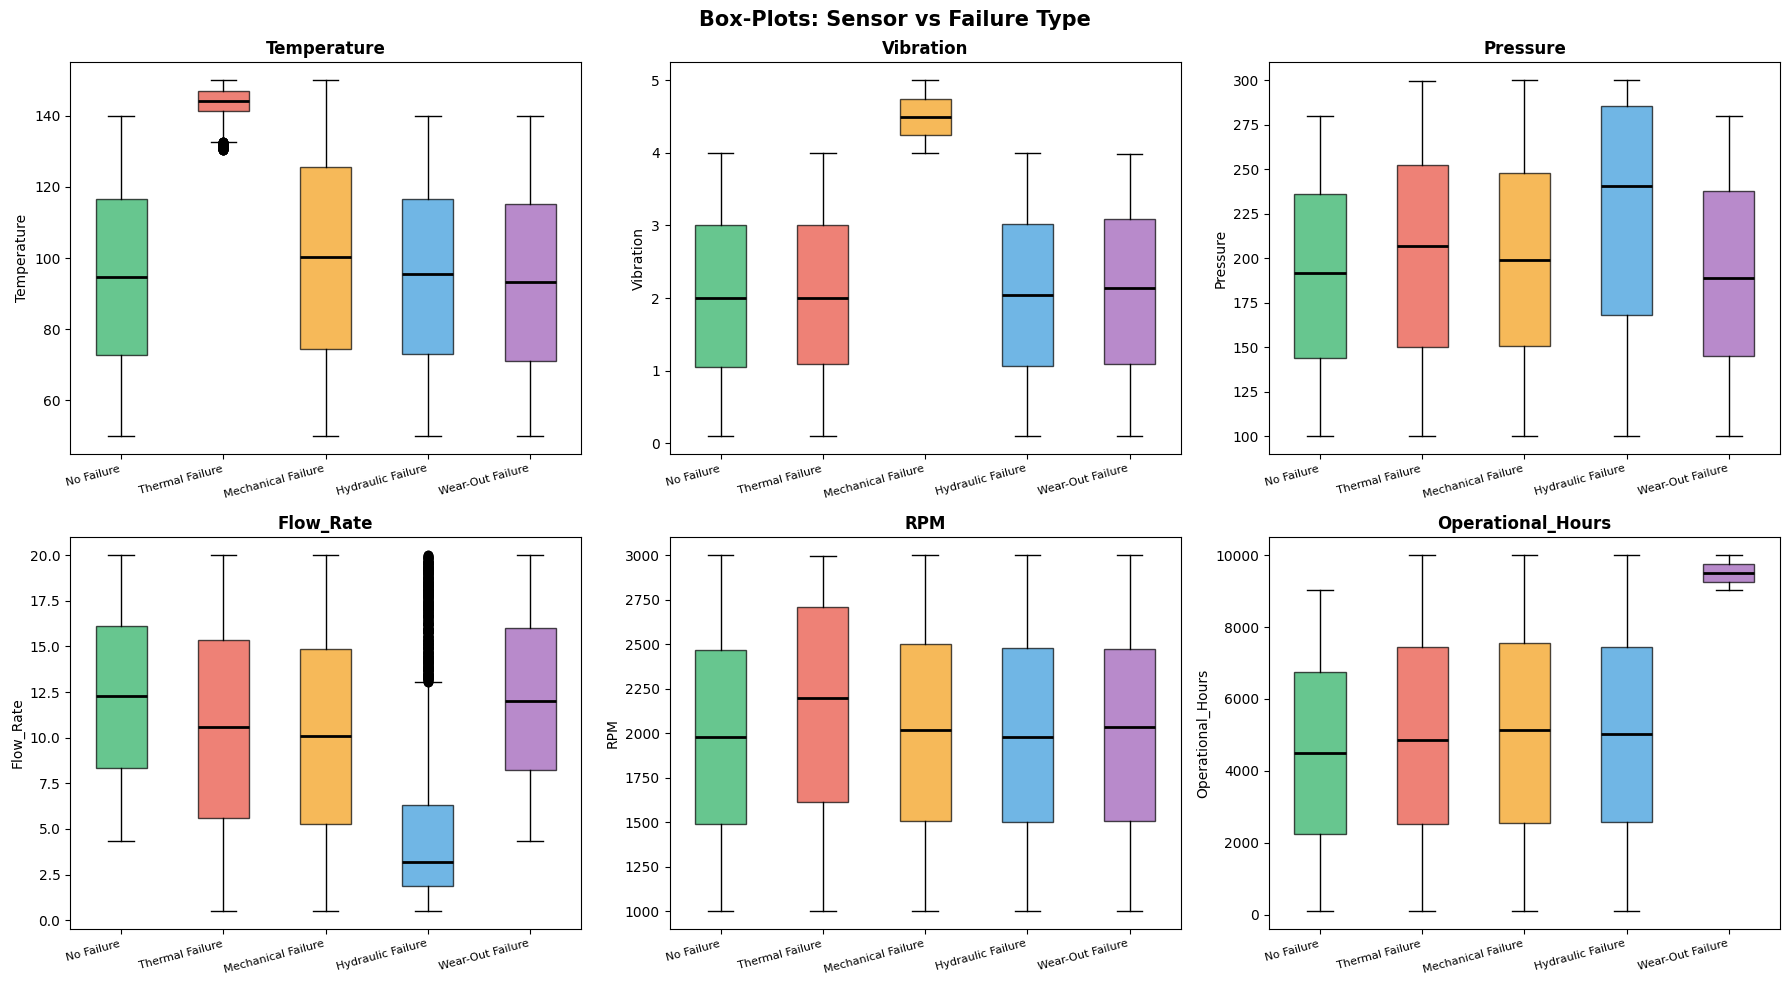

→ Saved: eda_boxplots.png


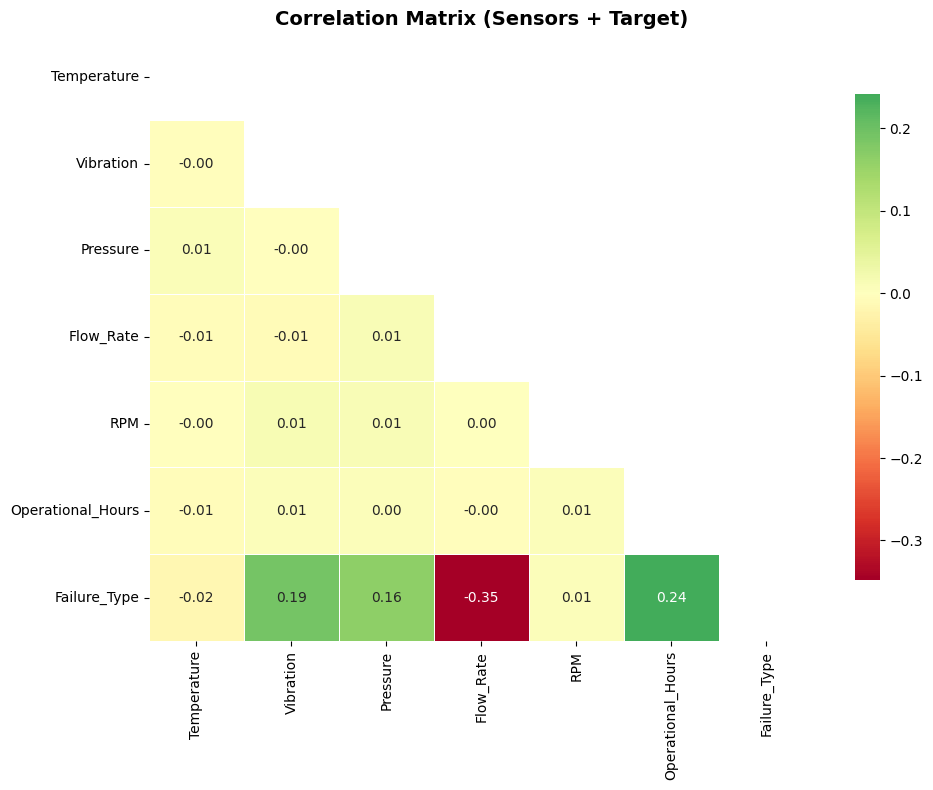

→ Saved: eda_correlation.png


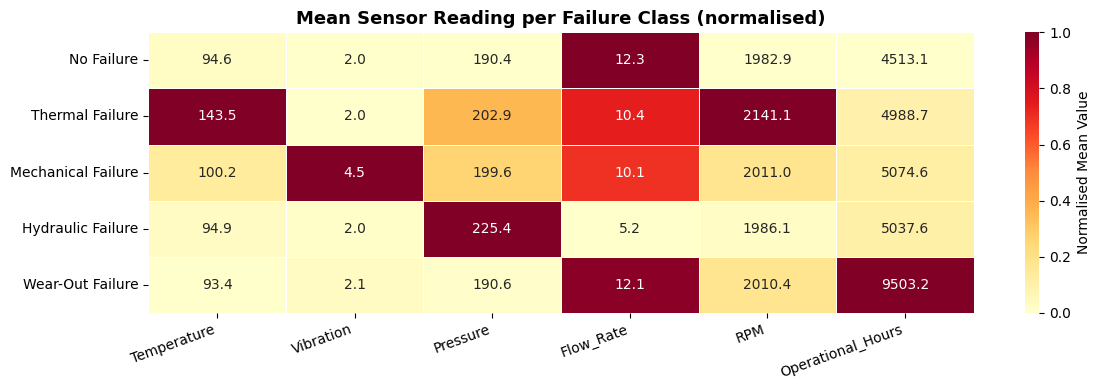

→ Saved: eda_mean_sensor_heatmap.png


In [6]:

banner("STEP 4 – EXPLORATORY DATA ANALYSIS")

sensor_cols  = ["Temperature","Vibration","Pressure","Flow_Rate","RPM","Operational_Hours"]
class_colors = PALETTE

# ── 4a. Failure type distribution pie + bar ───────────────────────────────────
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(14, 5))
fig.suptitle("Failure Type Distribution", fontsize=15, fontweight="bold")

counts = df["Failure_Type"].value_counts().sort_index()
ax1.pie(counts.values, labels=CLASS_NAMES, colors=PALETTE,
        autopct="%1.1f%%", startangle=140,
        wedgeprops=dict(edgecolor="white", linewidth=2))
ax1.set_title("Class Proportions")

bars = ax2.bar(CLASS_NAMES, counts.values, color=PALETTE, edgecolor="white", linewidth=1.5)
ax2.set_title("Class Counts")
ax2.set_ylabel("Number of Pumps")
ax2.set_xticklabels(CLASS_NAMES, rotation=15, ha="right")
for bar, val in zip(bars, counts.values):
    ax2.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 50,
             str(val), ha="center", fontweight="bold")

plt.tight_layout()
plt.savefig("eda_class_distribution.png", dpi=120, bbox_inches="tight")
plt.show()
print("→ Saved: eda_class_distribution.png")

# ── 4b. Sensor distributions by failure type ─────────────────────────────────
fig, axes = plt.subplots(2, 3, figsize=(18, 10))
fig.suptitle("Sensor Distributions by Failure Type", fontsize=15, fontweight="bold")

for ax, feat in zip(axes.flatten(), sensor_cols):
    for cls_id, color in zip(range(N_CLASSES), PALETTE):
        data = df[df["Failure_Type"] == cls_id][feat]
        ax.hist(data, bins=35, alpha=0.55, color=color,
                label=CLASS_NAMES[cls_id], density=True)
    ax.set_title(feat, fontweight="bold")
    ax.set_xlabel(feat)
    ax.set_ylabel("Density")
    ax.legend(fontsize=7)

plt.tight_layout()
plt.savefig("eda_sensor_distributions.png", dpi=120, bbox_inches="tight")
plt.show()
print("→ Saved: eda_sensor_distributions.png")

# ── 4c. Box-plots per failure type ───────────────────────────────────────────
fig, axes = plt.subplots(2, 3, figsize=(18, 10))
fig.suptitle("Box-Plots: Sensor vs Failure Type", fontsize=15, fontweight="bold")

for ax, feat in zip(axes.flatten(), sensor_cols):
    data_by_class = [df[df["Failure_Type"] == c][feat].values for c in range(N_CLASSES)]
    bp = ax.boxplot(data_by_class, patch_artist=True, notch=False,
                    medianprops=dict(color="black", linewidth=2))
    for patch, color in zip(bp["boxes"], PALETTE):
        patch.set_facecolor(color)
        patch.set_alpha(0.7)
    ax.set_title(feat, fontweight="bold")
    ax.set_xticklabels(CLASS_NAMES, rotation=15, ha="right", fontsize=8)
    ax.set_ylabel(feat)

plt.tight_layout()
plt.savefig("eda_boxplots.png", dpi=120, bbox_inches="tight")
plt.show()
print("→ Saved: eda_boxplots.png")

# ── 4d. Correlation heatmap ───────────────────────────────────────────────────
fig, ax = plt.subplots(figsize=(10, 8))
corr_cols = sensor_cols + ["Failure_Type"]
corr      = df[corr_cols].corr()
mask      = np.triu(np.ones_like(corr, dtype=bool))
sns.heatmap(corr, mask=mask, annot=True, fmt=".2f", cmap="RdYlGn",
            center=0, linewidths=0.5, ax=ax, cbar_kws={"shrink": 0.8})
ax.set_title("Correlation Matrix (Sensors + Target)", fontsize=14, fontweight="bold")
plt.tight_layout()
plt.savefig("eda_correlation.png", dpi=120, bbox_inches="tight")
plt.show()
print("→ Saved: eda_correlation.png")

# ── 4e. Mean sensor values per failure class (heatmap) ───────────────────────
fig, ax = plt.subplots(figsize=(12, 4))
mean_by_class = df.groupby("Failure_Type")[sensor_cols].mean()
mean_by_class.index = CLASS_NAMES
norm_means = (mean_by_class - mean_by_class.min()) / (mean_by_class.max() - mean_by_class.min())
sns.heatmap(norm_means, annot=mean_by_class.round(1), fmt=".1f",
            cmap="YlOrRd", linewidths=0.5, ax=ax,
            cbar_kws={"label": "Normalised Mean Value"})
ax.set_title("Mean Sensor Reading per Failure Class (normalised)", fontsize=13, fontweight="bold")
ax.set_xticklabels(ax.get_xticklabels(), rotation=20, ha="right")
plt.tight_layout()
plt.savefig("eda_mean_sensor_heatmap.png", dpi=120, bbox_inches="tight")
plt.show()
print("→ Saved: eda_mean_sensor_heatmap.png")


In [7]:

banner("STEP 5 – PREPROCESSING")

# Drop Pump_ID and the old binary Maintenance_Flag (replaced by Failure_Type)
drop_cols = ["Pump_ID", "Maintenance_Flag"]
df_model  = df.drop(columns=drop_cols)

X = df_model.drop(columns=["Failure_Type"])
y = df_model["Failure_Type"]

print(f"  Features : {X.shape[1]}  |  Samples : {X.shape[0]}")
print(f"  Classes  : {dict(y.value_counts().sort_index())}")

# Stratified 80 / 20 split
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.20, random_state=42, stratify=y
)
print(f"\n  Train set : {X_train.shape}  |  Test set : {X_test.shape}")

# Scale
scaler     = RobustScaler()
X_train_sc = scaler.fit_transform(X_train)
X_test_sc  = scaler.transform(X_test)
print("  Scaling   : RobustScaler ✓")

# Binarize labels for multi-class ROC
y_test_bin  = label_binarize(y_test,  classes=list(range(N_CLASSES)))
y_train_bin = label_binarize(y_train, classes=list(range(N_CLASSES)))




  STEP 5 – PREPROCESSING
  Features : 19  |  Samples : 20000
  Classes  : {0: np.int64(9104), 1: np.int64(1903), 2: np.int64(4000), 3: np.int64(3968), 4: np.int64(1025)}

  Train set : (16000, 19)  |  Test set : (4000, 19)
  Scaling   : RobustScaler ✓


In [8]:

banner("STEP 6 – MODEL TRAINING  (Multi-Class)")

models = {
    "Logistic Regression": LogisticRegression(
        max_iter=2000, class_weight="balanced",
        solver="lbfgs", random_state=42),

    "Decision Tree": DecisionTreeClassifier(
        max_depth=10, min_samples_leaf=15,
        class_weight="balanced", random_state=42),

    "Random Forest": RandomForestClassifier(
        n_estimators=200, max_depth=12, min_samples_leaf=10,
        class_weight="balanced", n_jobs=-1, random_state=42),

    "XGBoost": XGBClassifier(
        n_estimators=200, max_depth=6, learning_rate=0.05,
        subsample=0.8, colsample_bytree=0.8,
        objective="multi:softprob", num_class=N_CLASSES,
        use_label_encoder=False, eval_metric="mlogloss",
        random_state=42, n_jobs=-1),

    "SVM": SVC(
        kernel="rbf", C=1.0, gamma="scale",
        class_weight="balanced", probability=True, random_state=42),
}

needs_scaling = {"Logistic Regression", "SVM"}

results = {}

for name, model in models.items():
    print(f"\n  ▶  Training {name} …", end=" ", flush=True)

    _X_tr = X_train_sc if name in needs_scaling else X_train.values
    _X_te = X_test_sc  if name in needs_scaling else X_test.values

    t0 = time.time()
    model.fit(_X_tr, y_train)
    train_time = time.time() - t0

    y_pred  = model.predict(_X_te)
    y_prob  = model.predict_proba(_X_te)   # shape (n_samples, N_CLASSES)

    acc   = accuracy_score(y_test, y_pred)
    f1_w  = f1_score(y_test, y_pred, average="weighted",  zero_division=0)
    f1_m  = f1_score(y_test, y_pred, average="macro",     zero_division=0)
    prec  = precision_score(y_test, y_pred, average="weighted", zero_division=0)
    rec   = recall_score(y_test, y_pred, average="weighted",    zero_division=0)
    cm    = confusion_matrix(y_test, y_pred)

    # Per-class ROC-AUC (one-vs-rest)
    auc_scores = []
    fpr_dict, tpr_dict = {}, {}
    for i in range(N_CLASSES):
        if y_test_bin[:, i].sum() > 0:
            fpr, tpr, _ = roc_curve(y_test_bin[:, i], y_prob[:, i])
            auc_val     = auc(fpr, tpr)
            fpr_dict[i] = fpr
            tpr_dict[i] = tpr
        else:
            auc_val = float("nan")
        auc_scores.append(auc_val)

    macro_auc = np.nanmean(auc_scores)

    results[name] = {
        "Accuracy":         round(acc,        4),
        "Precision (W)":    round(prec,       4),
        "Recall (W)":       round(rec,        4),
        "F1 Weighted":      round(f1_w,       4),
        "F1 Macro":         round(f1_m,       4),
        "ROC-AUC (macro)":  round(macro_auc,  4),
        "Train Time (s)":   round(train_time, 3),
        "Confusion Matrix": cm,
        "y_pred":           y_pred,
        "y_prob":           y_prob,
        "fpr_dict":         fpr_dict,
        "tpr_dict":         tpr_dict,
        "auc_scores":       auc_scores,
    }

    print(f"done [{train_time:.2f}s]  Acc={acc:.4f}  F1_w={f1_w:.4f}  AUC={macro_auc:.4f}")



  STEP 6 – MODEL TRAINING  (Multi-Class)

  ▶  Training Logistic Regression … done [0.40s]  Acc=0.9103  F1_w=0.9120  AUC=0.9932

  ▶  Training Decision Tree … done [0.12s]  Acc=0.9962  F1_w=0.9962  AUC=0.9985

  ▶  Training Random Forest … done [0.39s]  Acc=0.9970  F1_w=0.9970  AUC=1.0000

  ▶  Training XGBoost … done [72.85s]  Acc=0.9945  F1_w=0.9945  AUC=1.0000

  ▶  Training SVM … done [7.87s]  Acc=0.8692  F1_w=0.8731  AUC=0.9942



  STEP 7 – EVALUATION & VISUALISATION

── Performance Summary (sorted by F1 Weighted) ──
                     Accuracy  Precision (W)  Recall (W)  F1 Weighted  F1 Macro  ROC-AUC (macro)  Train Time (s)
Random Forest          0.9970         0.9970      0.9970       0.9970    0.9939           1.0000           0.388
Decision Tree          0.9962         0.9963      0.9962       0.9962    0.9933           0.9985           0.118
XGBoost                0.9945         0.9945      0.9945       0.9945    0.9921           1.0000          72.854
Logistic Regression    0.9103         0.9224      0.9103       0.9120    0.8913           0.9932           0.401
SVM                    0.8692         0.8972      0.8692       0.8731    0.8434           0.9942           7.868

→ Saved: multiclass_model_comparison.csv


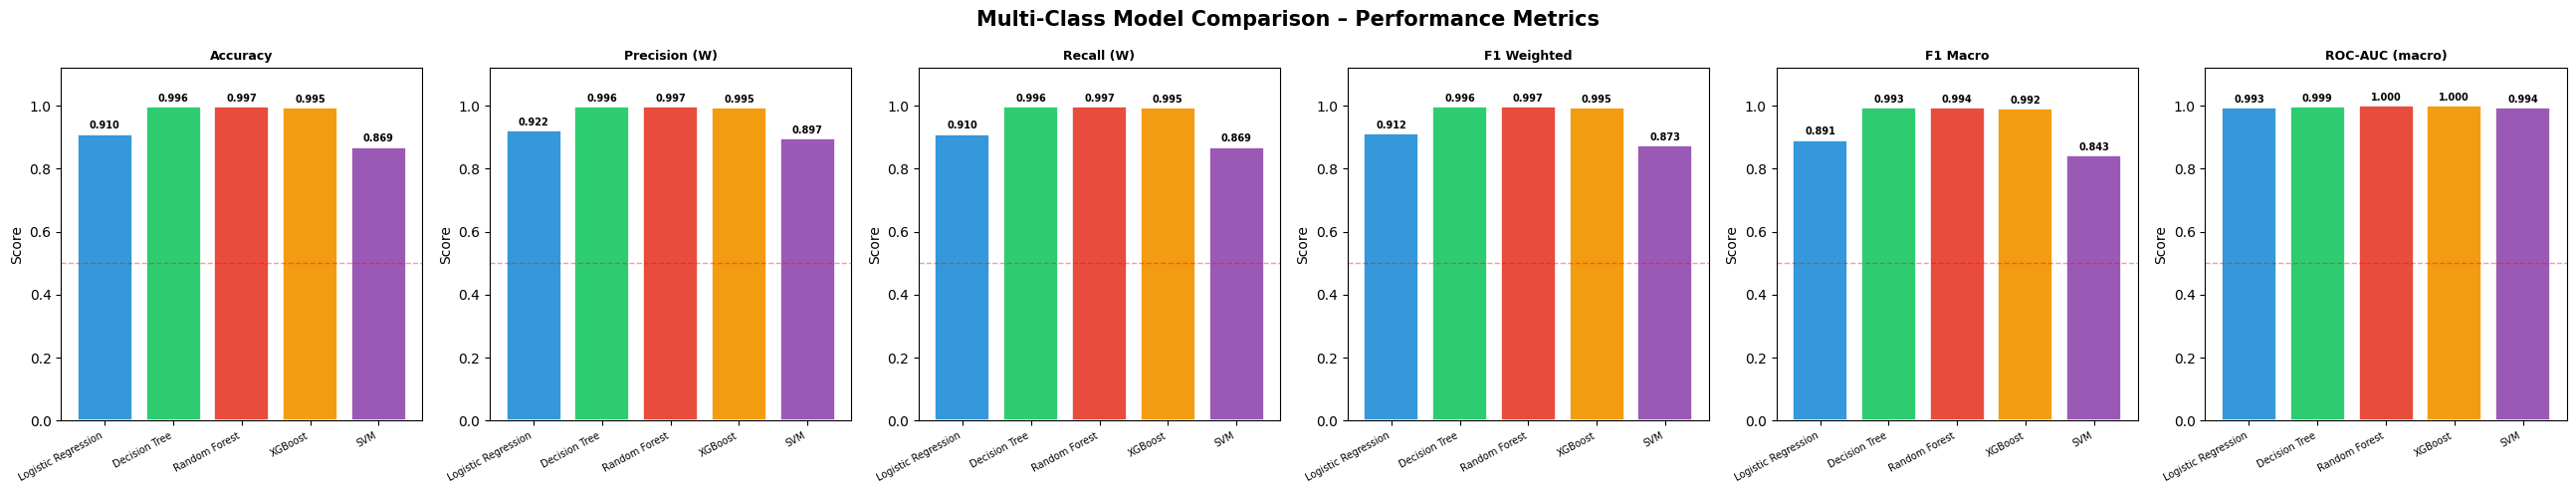

→ Saved: comparison_metrics_bar.png


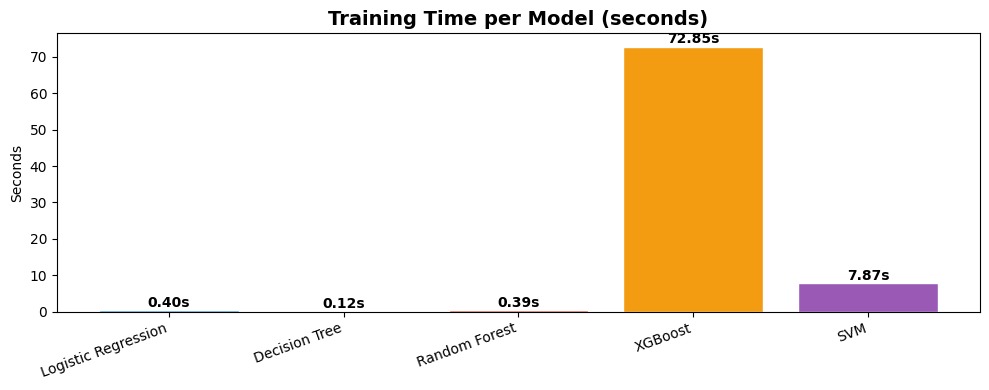

→ Saved: comparison_training_time.png


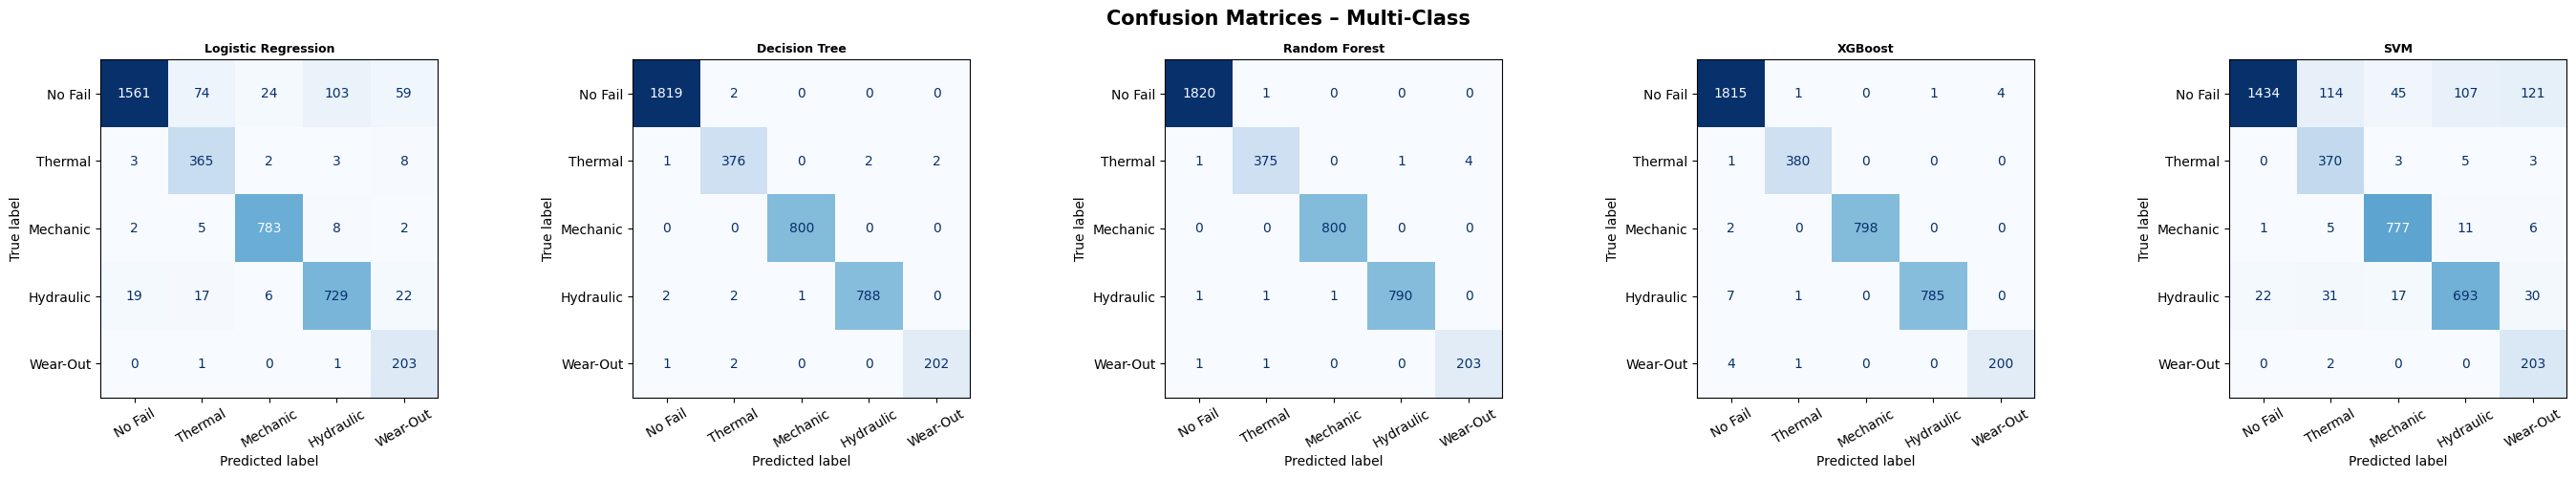

→ Saved: comparison_confusion_matrices.png


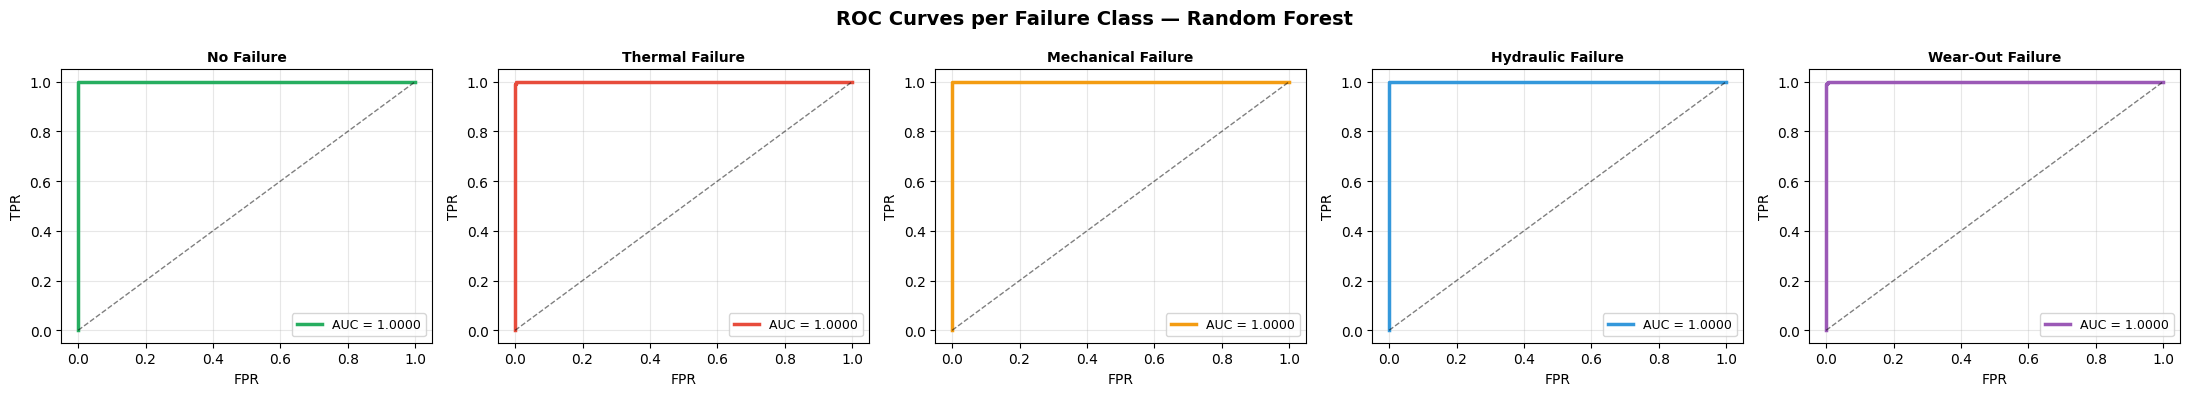

→ Saved: roc_curves_per_class.png  (Best model: Random Forest)


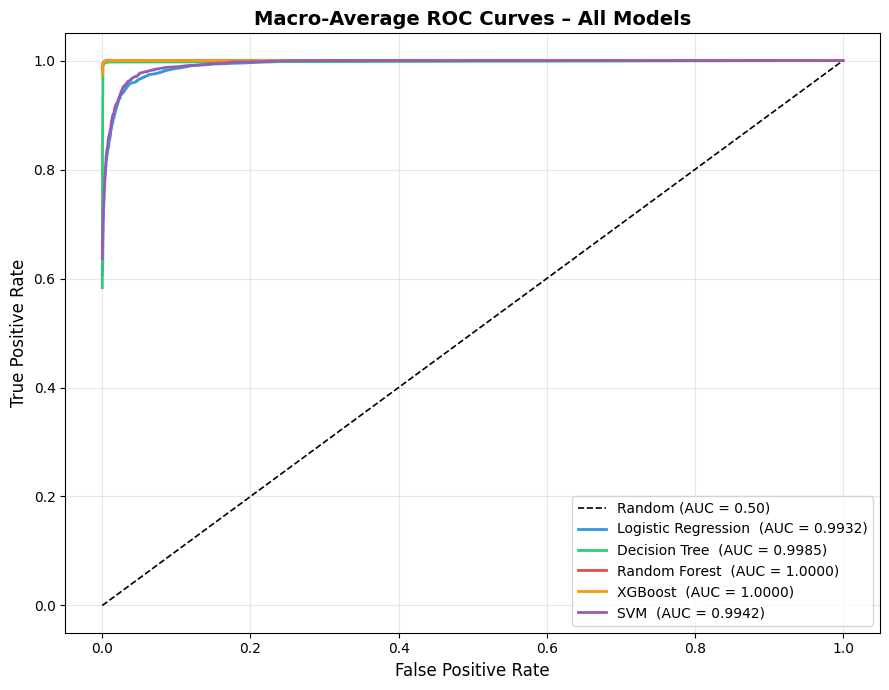

→ Saved: comparison_roc_curves.png


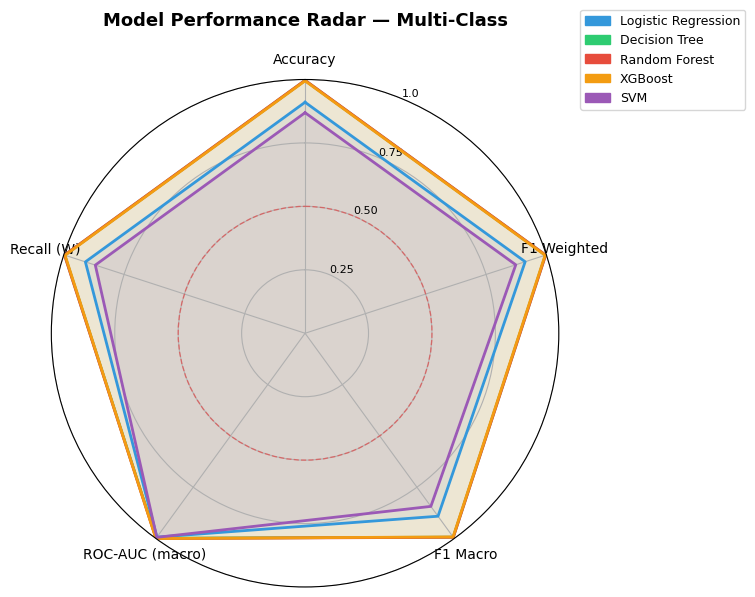

→ Saved: comparison_radar.png

  STEP 8 – FEATURE IMPORTANCE  (Random Forest)


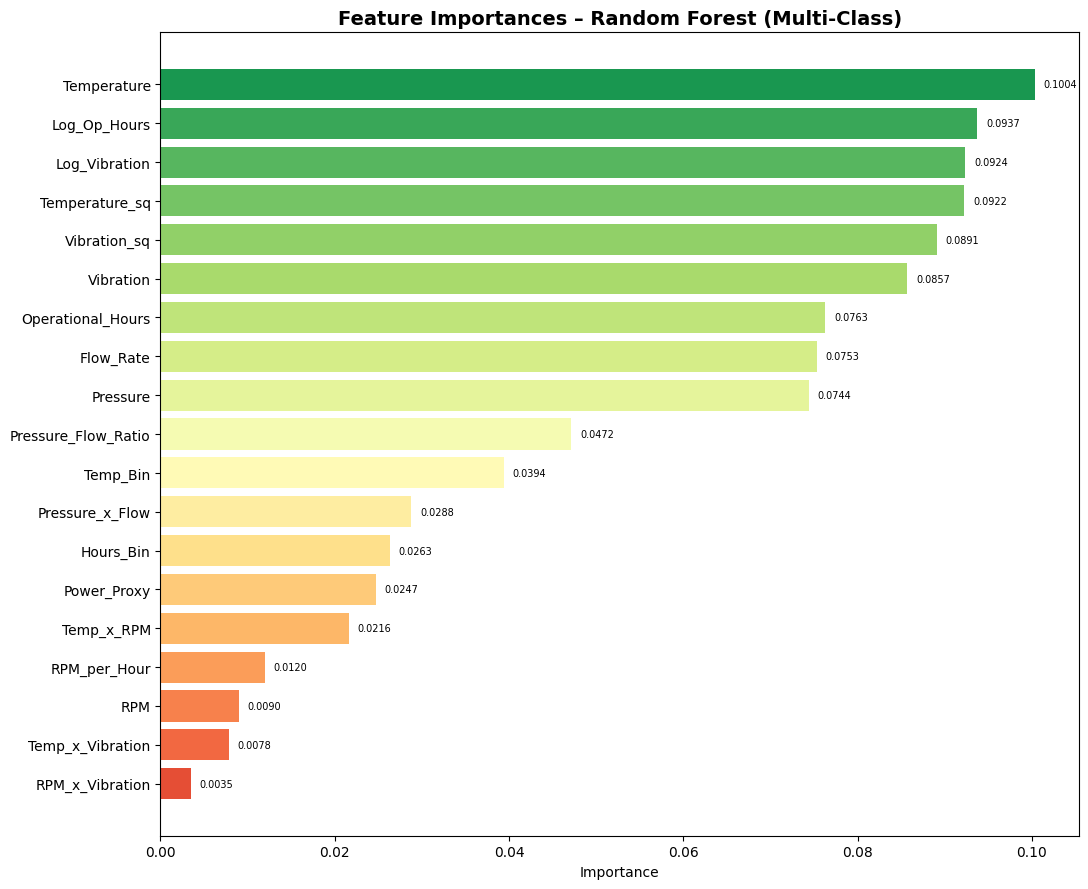

→ Saved: feature_importance_rf.png

  STEP 9 – PER-CLASS F1 SCORES


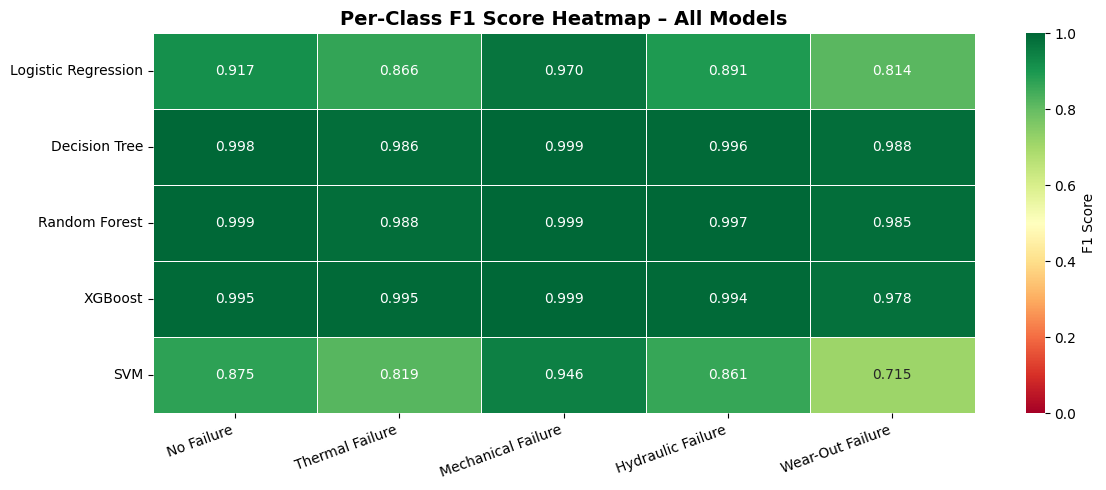

→ Saved: per_class_f1_heatmap.png

  STEP 10 – DETAILED CLASSIFICATION REPORTS

──────────────────────────────────────────────────
  Logistic Regression
──────────────────────────────────────────────────
                    precision    recall  f1-score   support

        No Failure       0.98      0.86      0.92      1821
   Thermal Failure       0.79      0.96      0.87       381
Mechanical Failure       0.96      0.98      0.97       800
 Hydraulic Failure       0.86      0.92      0.89       793
  Wear-Out Failure       0.69      0.99      0.81       205

          accuracy                           0.91      4000
         macro avg       0.86      0.94      0.89      4000
      weighted avg       0.92      0.91      0.91      4000


──────────────────────────────────────────────────
  Decision Tree
──────────────────────────────────────────────────
                    precision    recall  f1-score   support

        No Failure       1.00      1.00      1.00      1821
   Thermal Fa

In [ ]:

banner("STEP 7 – EVALUATION & VISUALISATION")

metric_keys = ["Accuracy","Precision (W)","Recall (W)","F1 Weighted","F1 Macro","ROC-AUC (macro)"]
summary = pd.DataFrame({
    name: {k: v for k, v in m.items() if k in metric_keys + ["Train Time (s)"]}
    for name, m in results.items()
}).T

print("\n── Performance Summary (sorted by F1 Weighted) ──")
print(summary.sort_values("F1 Weighted", ascending=False).to_string())
summary.to_csv("multiclass_model_comparison.csv")
print("\n→ Saved: multiclass_model_comparison.csv")

model_palette = ["#3498db","#2ecc71","#e74c3c","#f39c12","#9b59b6"]

# ── 7a. Metric comparison bars ───────────────────────────────────────────────
fig, axes = plt.subplots(1, len(metric_keys), figsize=(26, 5))
fig.suptitle("Multi-Class Model Comparison – Performance Metrics",
             fontsize=15, fontweight="bold")

for ax, metric in zip(axes, metric_keys):
    vals = [results[n][metric] for n in models]
    bars = ax.bar(models.keys(), vals, color=model_palette,
                  edgecolor="white", linewidth=1.2)
    ax.set_ylim(0, 1.12)
    ax.axhline(0.5, color="red", linestyle="--", linewidth=1, alpha=0.4)
    ax.set_title(metric, fontweight="bold", fontsize=9)
    ax.set_xticklabels(models.keys(), rotation=28, ha="right", fontsize=7)
    ax.set_ylabel("Score")
    for bar, val in zip(bars, vals):
        ax.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 0.01,
                f"{val:.3f}", ha="center", va="bottom", fontsize=7, fontweight="bold")

plt.tight_layout()
plt.savefig("comparison_metrics_bar.png", dpi=120, bbox_inches="tight")
plt.show()
print("→ Saved: comparison_metrics_bar.png")

# ── 7b. Training time ─────────────────────────────────────────────────────────
fig, ax = plt.subplots(figsize=(10, 4))
times = [results[n]["Train Time (s)"] for n in models]
bars  = ax.bar(models.keys(), times, color=model_palette, edgecolor="white")
ax.set_title("Training Time per Model (seconds)", fontsize=14, fontweight="bold")
ax.set_ylabel("Seconds")
ax.set_xticklabels(models.keys(), rotation=20, ha="right")
for bar, val in zip(bars, times):
    ax.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 0.05,
            f"{val:.2f}s", ha="center", va="bottom", fontsize=10, fontweight="bold")
plt.tight_layout()
plt.savefig("comparison_training_time.png", dpi=120, bbox_inches="tight")
plt.show()
print("→ Saved: comparison_training_time.png")

# ── 7c. Confusion matrices ────────────────────────────────────────────────────
fig, axes = plt.subplots(1, len(models), figsize=(28, 5))
fig.suptitle("Confusion Matrices – Multi-Class", fontsize=15, fontweight="bold")
short_names = ["No Fail","Thermal","Mechanic","Hydraulic","Wear-Out"]

for ax, (name, m) in zip(axes, results.items()):
    ConfusionMatrixDisplay(
        confusion_matrix=m["Confusion Matrix"],
        display_labels=short_names
    ).plot(ax=ax, colorbar=False, cmap="Blues", xticks_rotation=30)
    ax.set_title(name, fontsize=9, fontweight="bold")

plt.tight_layout()
plt.savefig("comparison_confusion_matrices.png", dpi=120, bbox_inches="tight")
plt.show()
print("→ Saved: comparison_confusion_matrices.png")

# ── 7d. ROC curves per class (best model = Random Forest) ────────────────────
best_model_name = summary.sort_values("F1 Weighted", ascending=False).index[0]
best            = results[best_model_name]

fig, axes = plt.subplots(1, N_CLASSES, figsize=(22, 4))
fig.suptitle(f"ROC Curves per Failure Class — {best_model_name}",
             fontsize=14, fontweight="bold")

for i, (ax, cname, color) in enumerate(zip(axes, CLASS_NAMES, PALETTE)):
    if i in best["fpr_dict"]:
        auc_val = best["auc_scores"][i]
        ax.plot(best["fpr_dict"][i], best["tpr_dict"][i],
                color=color, linewidth=2.5,
                label=f"AUC = {auc_val:.4f}")
    ax.plot([0,1],[0,1],"k--", linewidth=1, alpha=0.5)
    ax.set_title(cname, fontweight="bold", fontsize=10)
    ax.set_xlabel("FPR")
    ax.set_ylabel("TPR")
    ax.legend(fontsize=9)
    ax.grid(alpha=0.3)

plt.tight_layout()
plt.savefig("roc_curves_per_class.png", dpi=120, bbox_inches="tight")
plt.show()
print(f"→ Saved: roc_curves_per_class.png  (Best model: {best_model_name})")

# ── 7e. All models ROC macro comparison ──────────────────────────────────────
fig, ax = plt.subplots(figsize=(9, 7))
ax.plot([0,1],[0,1],"k--", linewidth=1.2, label="Random (AUC = 0.50)")

for (name, m), color in zip(results.items(), model_palette):
    # Micro-average across all classes
    all_fpr = np.unique(np.concatenate([m["fpr_dict"][i] for i in m["fpr_dict"]]))
    mean_tpr = np.zeros_like(all_fpr)
    for i in m["fpr_dict"]:
        mean_tpr += np.interp(all_fpr, m["fpr_dict"][i], m["tpr_dict"][i])
    mean_tpr /= len(m["fpr_dict"])
    macro_auc = auc(all_fpr, mean_tpr)
    ax.plot(all_fpr, mean_tpr, color=color, linewidth=2,
            label=f"{name}  (AUC = {macro_auc:.4f})")

ax.set_xlabel("False Positive Rate", fontsize=12)
ax.set_ylabel("True Positive Rate", fontsize=12)
ax.set_title("Macro-Average ROC Curves – All Models", fontsize=14, fontweight="bold")
ax.legend(loc="lower right", fontsize=10)
ax.grid(alpha=0.3)
plt.tight_layout()
plt.savefig("comparison_roc_curves.png", dpi=120, bbox_inches="tight")
plt.show()
print("→ Saved: comparison_roc_curves.png")

# ── 7f. Radar chart ───────────────────────────────────────────────────────────
radar_metrics = ["Accuracy","F1 Weighted","F1 Macro","ROC-AUC (macro)","Recall (W)"]
N_m    = len(radar_metrics)
angles = np.linspace(0, 2*np.pi, N_m, endpoint=False).tolist() + \
         [np.linspace(0, 2*np.pi, N_m, endpoint=False)[0]]

fig, ax = plt.subplots(figsize=(8, 8), subplot_kw=dict(polar=True))
ax.set_theta_offset(np.pi/2)
ax.set_theta_direction(-1)
ax.set_xticks(angles[:-1])
ax.set_xticklabels(radar_metrics, fontsize=10)
ax.set_ylim(0, 1)
ax.set_yticks([0.25, 0.50, 0.75, 1.0])
ax.set_yticklabels(["0.25","0.50","0.75","1.0"], fontsize=8)
ax.axhline(0.5, color="red", linestyle="--", linewidth=1, alpha=0.4)

patches = []
for (name, m), color in zip(results.items(), model_palette):
    vals = [m[met] for met in radar_metrics] + [m[radar_metrics[0]]]
    ax.plot(angles, vals, color=color, linewidth=2)
    ax.fill(angles, vals, color=color, alpha=0.08)
    patches.append(mpatches.Patch(color=color, label=name))

ax.legend(handles=patches, loc="upper right",
          bbox_to_anchor=(1.38, 1.15), fontsize=9)
ax.set_title("Model Performance Radar — Multi-Class", fontsize=13,
             fontweight="bold", pad=20)
plt.tight_layout()
plt.savefig("comparison_radar.png", dpi=120, bbox_inches="tight")
plt.show()
print("→ Saved: comparison_radar.png")

# ── 7g. Feature importance (Random Forest) ────────────────────────────────────
banner("STEP 8 – FEATURE IMPORTANCE  (Random Forest)")

rf    = models["Random Forest"]
imps  = pd.Series(rf.feature_importances_, index=X.columns).sort_values(ascending=True)

fig, ax = plt.subplots(figsize=(11, 9))
colors_imp = plt.cm.RdYlGn(np.linspace(0.15, 0.9, len(imps)))
ax.barh(imps.index, imps.values, color=colors_imp)
ax.set_title("Feature Importances – Random Forest (Multi-Class)",
             fontsize=14, fontweight="bold")
ax.set_xlabel("Importance")
for i, (feat, val) in enumerate(zip(imps.index, imps.values)):
    ax.text(val + 0.001, i, f"{val:.4f}", va="center", fontsize=7)
plt.tight_layout()
plt.savefig("feature_importance_rf.png", dpi=120, bbox_inches="tight")
plt.show()
print("→ Saved: feature_importance_rf.png")

# ── 7h. Per-class F1 heatmap ─────────────────────────────────────────────────
banner("STEP 9 – PER-CLASS F1 SCORES")

per_class_f1 = {}
for name, m in results.items():
    report = classification_report(y_test, m["y_pred"], output_dict=True, zero_division=0)
    per_class_f1[name] = {CLASS_NAMES[int(k)]: v["f1-score"]
                          for k, v in report.items()
                          if k.isdigit()}

f1_df = pd.DataFrame(per_class_f1).T

fig, ax = plt.subplots(figsize=(12, 5))
sns.heatmap(f1_df, annot=True, fmt=".3f", cmap="RdYlGn",
            vmin=0, vmax=1, linewidths=0.5, ax=ax,
            cbar_kws={"label": "F1 Score"})
ax.set_title("Per-Class F1 Score Heatmap – All Models",
             fontsize=14, fontweight="bold")
ax.set_xticklabels(ax.get_xticklabels(), rotation=20, ha="right")
plt.tight_layout()
plt.savefig("per_class_f1_heatmap.png", dpi=120, bbox_inches="tight")
plt.show()
print("→ Saved: per_class_f1_heatmap.png")

# ── 7i. Classification reports ───────────────────────────────────────────────
banner("STEP 10 – DETAILED CLASSIFICATION REPORTS")
for name, m in results.items():
    print(f"\n{'─'*50}\n  {name}\n{'─'*50}")
    print(classification_report(y_test, m["y_pred"],
                                target_names=CLASS_NAMES, zero_division=0))


In [ ]:

banner("STEP 11 – SAVING FINAL ENGINEERED DATASET")

df.to_csv("Pump_Multiclass_Engineered_Dataset.csv", index=False)
print(f"  Saved: Pump_Multiclass_Engineered_Dataset.csv")
print(f"  Shape: {df.shape}")
print(f"  Columns ({len(df.columns)}):")
for col in df.columns:
    marker = " ← NEW" if col not in ["Pump_ID","Temperature","Vibration",
                                      "Pressure","Flow_Rate","RPM",
                                      "Operational_Hours","Maintenance_Flag"] else ""
    print(f"    {col}{marker}")

# ── Final summary ─────────────────────────────────────────────────────────────
banner("✅  FINAL RANKED SUMMARY")
print(summary.sort_values("F1 Weighted", ascending=False).to_string())

print("\n  Output files generated:")
for f in [
    "eda_class_distribution.png",    "eda_sensor_distributions.png",
    "eda_boxplots.png",              "eda_correlaontion.png",
    "eda_mean_sensor_heatmap.png",   "comparison_metrics_bar.png",
    "comparison_training_time.png",  "comparison_confusion_matrices.png",
    "roc_curves_per_class.png",      "comparison_roc_curves.png",
    "comparison_radar.png",          "feature_importance_rf.png",
    "per_class_f1_heatmap.png",      "multiclass_model_comparison.csv",
    "Pump_Multiclass_Engineered_Dataset.csv"
]:
    print(f"   📄 {f}")



  STEP 11 – SAVING FINAL ENGINEERED DATASET
  Saved: Pump_Multiclass_Engineered_Dataset.csv
  Shape: (20000, 22)
  Columns (22):
    Pump_ID
    Temperature
    Vibration
    Pressure
    Flow_Rate
    RPM
    Operational_Hours
    Maintenance_Flag
    Failure_Type ← NEW
    Temp_x_Vibration ← NEW
    Pressure_x_Flow ← NEW
    RPM_x_Vibration ← NEW
    Temp_x_RPM ← NEW
    Pressure_Flow_Ratio ← NEW
    RPM_per_Hour ← NEW
    Power_Proxy ← NEW
    Log_Vibration ← NEW
    Log_Op_Hours ← NEW
    Temperature_sq ← NEW
    Vibration_sq ← NEW
    Hours_Bin ← NEW
    Temp_Bin ← NEW

  ✅  FINAL RANKED SUMMARY
                     Accuracy  Precision (W)  Recall (W)  F1 Weighted  F1 Macro  ROC-AUC (macro)  Train Time (s)
Random Forest          0.9970         0.9970      0.9970       0.9970    0.9939           1.0000           0.388
Decision Tree          0.9962         0.9963      0.9962       0.9962    0.9933           0.9985           0.118
XGBoost                0.9945         0.9945      0.